Treino

Bloco 1 concluído: Modelo treinado e ficheiros guardados!


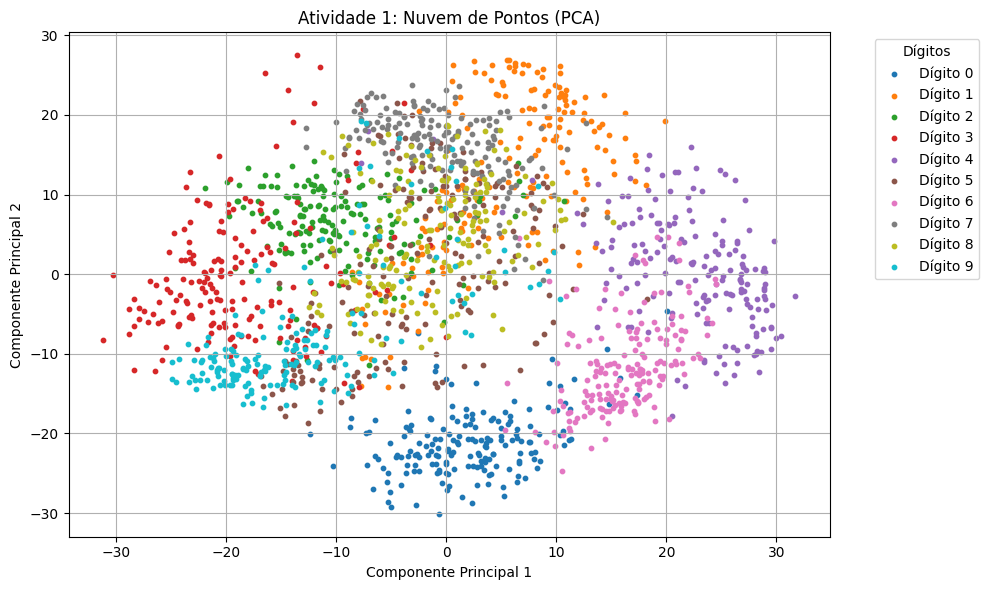

In [ ]:
import matplotlib.pyplot as plt
import joblib
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

digits = datasets.load_digits()
X = digits.data
y = digits.target

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=1/3, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

joblib.dump(knn, 'modelo_knn_digits.pkl')
joblib.dump([X_test, y_test], 'dados_teste.pkl')

print("Bloco 1 concluído: Modelo treinado e ficheiros guardados!")

plt.figure(figsize=(10, 6))

# Obtém todos os dígitos únicos para garantir que a legenda seja consistente
unique_digits = sorted(list(set(y)))
# Usando 'tab10' para cores distintas
colors = plt.cm.tab10(range(len(unique_digits)))

for i, digit in enumerate(unique_digits):
    # Plota pontos para cada dígito com uma cor e rótulo específicos
    idx = (y == digit)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], color=colors[i], s=10, label=f'Dígito {digit}')

plt.title("Atividade 1: Nuvem de Pontos (PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
# Move a legenda para fora do plot
plt.legend(title="Dígitos", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
# Ajusta o layout para evitar que os rótulos sejam cortados
plt.tight_layout()
plt.show()

Teste

Bloco 2 concluído!
Precisão do Modelo nos dados de teste: 63.11%


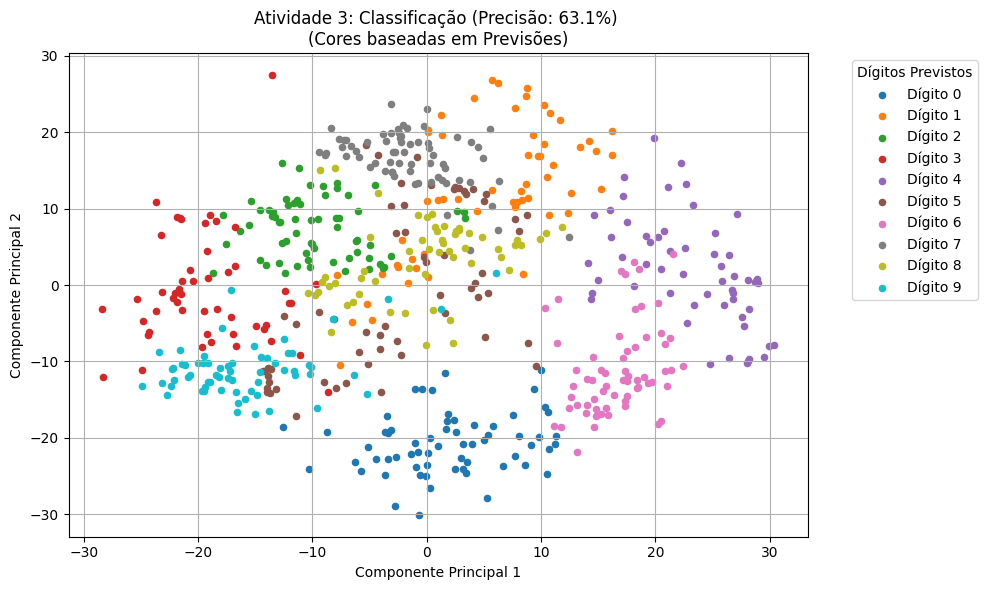

In [ ]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

modelo_carregado = joblib.load('modelo_knn_digits.pkl')
dados = joblib.load('dados_teste.pkl')
X_reserva = dados[0]
y_reserva = dados[1]

previsoes = modelo_carregado.predict(X_reserva)

precisao = accuracy_score(y_reserva, previsoes)
print(f"Bloco 2 concluído!")
print(f"Precisão do Modelo nos dados de teste: {precisao * 100:.2f}%")

plt.figure(figsize=(10, 6)) # Aumenta o tamanho da figura para acomodar a legenda fora

# Obtém todos os dígitos possíveis (0-9) para garantir que a legenda seja consistente
all_digits = range(10) # Dígitos de 0 a 9
colors = plt.cm.tab10(range(len(all_digits))) # Usando tab10 para cores distintas

for i, digit in enumerate(all_digits):
    # Plota pontos para cada dígito previsto com uma cor e rótulo específicos
    idx = (previsoes == digit)
    if idx.any(): # Só plota se houver previsões para este dígito
        plt.scatter(X_reserva[idx, 0], X_reserva[idx, 1], color=colors[i], s=20, label=f'Dígito {digit}')

plt.title(f"Atividade 3: Classificação (Precisão: {precisao*100:.1f}%) \n(Cores baseadas em Previsões)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Dígitos Previstos", bbox_to_anchor=(1.05, 1), loc='upper left') # Move a legenda para fora
plt.grid(True)
plt.tight_layout() # Ajusta o layout para evitar que os rótulos sejam cortados
plt.show()

Previsão

In [ ]:
import joblib

modelo_final = joblib.load('modelo_knn_digits.pkl')
dados_finais = joblib.load('dados_teste.pkl')
X_reserva = dados_finais[0]
y_reserva = dados_finais[1]

n = 10
ponto = [X_reserva[n]]#.reshape(1, -1)
previsao_unica = modelo_final.predict(ponto)
print(f"Predição para o ponto {n}: {previsao_unica[0]}")

Predição para o ponto 10: 7
